# Despliegue Edge Local — Pipeline Monedas Colombianas

Notebook **independiente** para ejecutar inferencia local sobre imágenes, carpetas, video archivo y webcam,
sin Colab y sin Google Drive. Usa los pesos finales `models/best_final.pt`.

## Pre-requisitos

1. Python 3.10+ con `requirements.txt` instalado en un venv local.
2. `models/best_final.pt` descargado desde `MyDrive/DeteccionMonedas/models/` (~50 MB).
3. Imágenes en `data/samples/` para las demos de imagen única y carpeta.
4. `data/samples/video_test.mp4` para la demo de video archivo.
5. Cámara web conectada para la demo de webcam en vivo.

## 0. Setup local

In [1]:
!pip install -r requirements.txt

In [2]:
%matplotlib inline

from collections import Counter, deque
from pathlib import Path
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# Reproducibilidad (consistente con el notebook maestro)
torch.manual_seed(42)
np.random.seed(42)

# Paths locales (relativos al working dir del notebook)
PROJECT_ROOT = Path.cwd()
WEIGHTS_PATH = PROJECT_ROOT / 'models' / 'best_final.pt'
SAMPLES_DIR  = PROJECT_ROOT / 'data' / 'samples'
VIDEO_PATH   = SAMPLES_DIR / 'video_test.mp4'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'edge'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Forzamos CPU explícitamente
device = 'cpu'

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'Device       : {device}')
print(f'PyTorch      : {torch.__version__}')
print(f'OpenCV       : {cv2.__version__}')

# Mapeo de clases
CLASS_VALUES = {
    'moneda_50': 50, 'moneda_100': 100, 'moneda_200': 200,
    'moneda_500': 500, 'moneda_1000': 1000,
    'billete_10000': 10000, 'billete_20000': 20000, 'billete_50000': 50000,
}

# Thresholds de inferencia
CONF_THRESHOLD = 0.4
IOU_THRESHOLD  = 0.5
IMG_SIZE       = 640

# Hiperparámetros de video / tracking (V2)
VIDEO_CONF        = 0.5
V2_WINDOW         = 7
V2_MIN_HITS       = 4
V2_MAX_GAP        = 10
V2_DISPLAY_WINDOW = 15

# Webcam: flag de seguridad para 'Run All'
RUN_WEBCAM        = True     # cambia a True para ejecutar la demo de webcam
SAVE_WEBCAM       = True      # graba a disco si la demo se ejecuta
WEBCAM_INDEX      = 0         # /dev/video0
WEBCAM_MAX_FRAMES = 600       # tope ~20s @ 30fps para evitar bloqueos accidentales


PROJECT_ROOT : /media/wills/Study/Maestría en Inteligecia Artificial/Semestre II/Proyecto Innovación 2/DeteccionMonedas/contador-divisas-colombia
Device       : cpu
PyTorch      : 2.11.0+cpu
OpenCV       : 4.13.0


## 1. Funciones core (duplicadas del notebook maestro, autocontenidas)

In [3]:
def format_currency(value: int) -> str:
    """Formato '$1.500' con separador de miles estilo COP."""
    return f'${value:,.0f}'.replace(',', '.')


def build_message(counts_by_class: dict) -> str:
    """Genera el mensaje en formato literal de la rúbrica."""
    if not counts_by_class:
        return 'No se detectó ninguna divisa en la escena. Total en escena: $0'
    parts = []
    for class_name, count in sorted(counts_by_class.items(),
                                     key=lambda kv: CLASS_VALUES.get(kv[0], 0)):
        if class_name.startswith('moneda_'):
            valor = class_name.split('_')[1]
            sustantivo = 'moneda' if count == 1 else 'monedas'
            parts.append(f'{count} {sustantivo} de {valor}')
        elif class_name.startswith('billete_'):
            valor = int(class_name.split('_')[1])
            sustantivo = 'billete' if count == 1 else 'billetes'
            parts.append(f'{count} {sustantivo} de {format_currency(valor)}')
        else:
            parts.append(f'{count} × {class_name}')
    listado = parts[0] if len(parts) == 1 else ', '.join(parts[:-1]) + ' y ' + parts[-1]
    total = sum(CLASS_VALUES[c] * n for c, n in counts_by_class.items())
    return f'Se detectaron {listado}. Total en escena: {format_currency(total)}'


def quantify_local(model, image_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    """Inferencia + cuantificación local sobre una imagen.

    Igual que `quantify()` del maestro pero:
    - device='cpu' explícito
    - imgsz explícito en model.predict
    - retorna también latency_ms para el reporte edge.
    """
    t0 = time.time()
    results = model.predict(source=str(image_path), conf=conf, iou=iou,
                            imgsz=imgsz, device=device, verbose=False)
    latency_ms = (time.time() - t0) * 1000.0
    r = results[0]
    cls_indices = r.boxes.cls.int().tolist() if r.boxes is not None else []
    class_names = [model.names[i] for i in cls_indices]
    counts = Counter(class_names)
    total = sum(CLASS_VALUES[c] * n for c, n in counts.items())
    message = build_message(dict(counts))
    annotated_bgr = r.plot()
    h, w = annotated_bgr.shape[:2]
    overlay_h = max(70, int(h * 0.10))
    bar = np.full((overlay_h, w, 3), 32, dtype=np.uint8)
    cv2.putText(bar, f'TOTAL: {format_currency(total)}', (15, int(overlay_h * 0.55)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 180), 3)
    annotated_bgr = np.vstack([bar, annotated_bgr])
    return {
        'image_path'   : str(image_path),
        'counts'       : dict(counts),
        'total'        : total,
        'message'      : message,
        'annotated_bgr': annotated_bgr,
        'n_detections' : len(class_names),
        'latency_ms'   : latency_ms,
    }


print('Funciones definidas: format_currency, build_message, quantify_local')


Funciones definidas: format_currency, build_message, quantify_local


In [4]:
class StableCounter:
    """V1 — copia textual de pipeline_monedas.ipynb cell 51.

    Mantiene historial por track_id y decide si contar (>=min_hits visto en window
    frames) y qué clase asignar (voto mayoritario sobre el historial).
    """
    def __init__(self, window=5, min_hits=3, max_gap=10):
        self.window = window
        self.min_hits = min_hits
        self.max_gap = max_gap
        self.history: dict[int, deque] = {}
        self.last_seen: dict[int, int] = {}
        self.frame_idx = 0

    def update(self, tracks):
        """tracks: lista de (tid, class_name, conf). Devuelve [(tid, voted_class)]."""
        self.frame_idx += 1
        for tid, cls_name, _conf in tracks:
            if tid not in self.history:
                self.history[tid] = deque(maxlen=self.window)
            self.history[tid].append(cls_name)
            self.last_seen[tid] = self.frame_idx
        # Limpiar tracks muertos
        stale = [tid for tid, fi in self.last_seen.items()
                 if self.frame_idx - fi > self.max_gap]
        for tid in stale:
            del self.history[tid]
            del self.last_seen[tid]
        # Confirmar tracks visibles en este frame con suficiente historial
        confirmed = []
        for tid, hist in self.history.items():
            if len(hist) >= self.min_hits and self.last_seen[tid] == self.frame_idx:
                voted_class = Counter(hist).most_common(1)[0][0]
                confirmed.append((tid, voted_class))
        return confirmed

    def stable_total(self, confirmed):
        return sum(CLASS_VALUES.get(cls, 0) for _, cls in confirmed)


class StableCounterV2(StableCounter):
    """V2 — copia textual de pipeline_monedas.ipynb cell 57.

    Añade mediana móvil sobre el total a lo largo de los últimos `display_window`
    frames para suavizar el HUD sin afectar la lógica de conteo.
    """
    def __init__(self, window=V2_WINDOW, min_hits=V2_MIN_HITS,
                 max_gap=V2_MAX_GAP, display_window=V2_DISPLAY_WINDOW):
        super().__init__(window=window, min_hits=min_hits, max_gap=max_gap)
        self.display_window = display_window
        self._total_history: deque = deque(maxlen=display_window)

    def display_total(self, confirmed):
        """Total suavizado por mediana móvil — solo para visualización."""
        current = self.stable_total(confirmed)
        self._total_history.append(current)
        sorted_hist = sorted(self._total_history)
        n = len(sorted_hist)
        if n % 2 == 1:
            return sorted_hist[n // 2]
        return (sorted_hist[n // 2 - 1] + sorted_hist[n // 2]) // 2


print('Estabilizadores definidos: StableCounter (V1), StableCounterV2')


Estabilizadores definidos: StableCounter (V1), StableCounterV2


## 2. Cargar modelo final

In [5]:
model = YOLO(str(WEIGHTS_PATH))
print(f'Modelo cargado: {WEIGHTS_PATH}')
print(f'Clases ({len(model.names)}): {list(model.names.values())}')

# Sanity check: todas las clases del modelo deben estar mapeadas a un valor monetario
missing = [c for c in model.names.values() if c not in CLASS_VALUES]
assert not missing, f'Clases sin valor mapeado en CLASS_VALUES: {missing}'
print('CLASS_VALUES cubre todas las clases del modelo.')


Modelo cargado: /media/wills/Study/Maestría en Inteligecia Artificial/Semestre II/Proyecto Innovación 2/DeteccionMonedas/contador-divisas-colombia/models/best_final.pt
Clases (8): ['billete_10000', 'billete_20000', 'billete_50000', 'moneda_100', 'moneda_1000', 'moneda_200', 'moneda_50', 'moneda_500']
CLASS_VALUES cubre todas las clases del modelo.


## 3. Inferencia de una imagen

Toma la primera imagen disponible en `data/samples/`, ejecuta `quantify_local()`,
guarda la versión anotada en `outputs/edge/pred_single_<nombre>.jpg` y muestra
el mensaje.

Imagen   : IMG_20260502_082341_1.jpg
Mensaje  : Se detectaron 2 monedas de 50, 6 monedas de 200, 1 moneda de 500, 5 monedas de 1000, 1 billete de $20.000 y 1 billete de $50.000. Total en escena: $76.800
Latencia : 386.5 ms
Salida   : /media/wills/Study/Maestría en Inteligecia Artificial/Semestre II/Proyecto Innovación 2/DeteccionMonedas/contador-divisas-colombia/outputs/edge/pred_single_IMG_20260502_082341_1.jpg


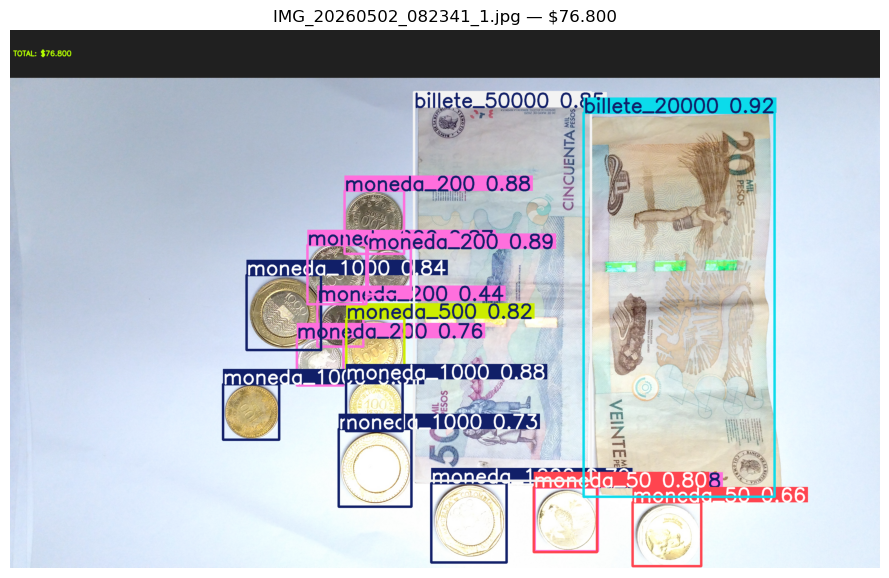

In [7]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}
sample_images = sorted([
    p for p in SAMPLES_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTS
]) if SAMPLES_DIR.exists() else []

if not sample_images:
    print(f'No hay imágenes en {SAMPLES_DIR}.')
    print('Sube al menos una foto (.jpg/.png) para ejecutar las demos 3 y 4.')
    single_result = None
else:
    img_path = sample_images[0]
    single_result = quantify_local(model, img_path)
    out_path = OUTPUT_DIR / f'pred_single_{img_path.stem}.jpg'
    cv2.imwrite(str(out_path), single_result['annotated_bgr'])

    print(f'Imagen   : {img_path.name}')
    print(f'Mensaje  : {single_result["message"]}')
    print(f'Latencia : {single_result["latency_ms"]:.1f} ms')
    print(f'Salida   : {out_path}')

    plt.figure(figsize=(9, 7))
    plt.imshow(cv2.cvtColor(single_result['annotated_bgr'], cv2.COLOR_BGR2RGB))
    plt.title(f'{img_path.name} — {format_currency(single_result["total"])}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## 4. Inferencia: carpeta de imágenes

Itera todas las imágenes en `data/samples/`, las procesa con `quantify_local()`,
guarda cada versión anotada en `outputs/edge/pred_folder_<nombre>.jpg` y arma
una galería matplotlib + tabla resumen con detecciones, total y latencia por imagen.

In [ ]:
if not sample_images:
    print(f'Sin imágenes en {SAMPLES_DIR}; saltando demo de carpeta.')
    folder_results = []
else:
    folder_results = []
    for img_path in sample_images:
        out = quantify_local(model, img_path)
        out_path = OUTPUT_DIR / f'pred_folder_{img_path.stem}.jpg'
        cv2.imwrite(str(out_path), out['annotated_bgr'])
        folder_results.append({
            **{k: v for k, v in out.items() if k != 'annotated_bgr'},
            'output_path': str(out_path),
        })

    # ---- Galería ----
    n = len(folder_results)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes_flat = list(np.atleast_1d(axes).flat)
    for ax, log in zip(axes_flat, folder_results):
        img_bgr = cv2.imread(log['output_path'])
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(Path(log['image_path']).name, fontsize=10)
        ax.axis('off')
    for ax in axes_flat[len(folder_results):]:
        ax.axis('off')
    plt.suptitle(f'Inferencia edge sobre {n} imágenes locales (CPU)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ---- Tabla ----
    df_folder = pd.DataFrame([
        {'imagen'      : Path(r['image_path']).name,
         'detecciones' : r['n_detections'],
         'total_$'     : r['total'],
         'latencia_ms' : round(r['latency_ms'], 1),
         'mensaje'     : r['message']}
        for r in folder_results
    ])
    print('\nResumen edge (carpeta):')
    print(df_folder.to_string(index=False))


## 5. Inferencia: video archivo

Procesa el video completo aplicando ByteTrack + `StableCounterV2`, escribe
`outputs/edge/edge_video_v2.mp4` y muestra al final 3 frames de muestra inline.

**Métrica reportada:** wall-clock real (incluye escritura a disco) → FPS edge.

Video: 848x478 @ 23.9 fps, 1306 frames
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.5 environment at: /home/wills/anaconda3/envs/master-IA
Resolved 2 packages in 757ms
 Downloaded lap
Prepared 1 package in 416ms
Installed 1 package in 16ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  procesado frame 60/1306
  procesado frame 120/1306
  procesado frame 180/1306
  procesado frame 240/1306
  procesado frame 300/1306
  procesado frame 360/1306
  procesado frame 420/1306
  procesado frame 480/1306
  procesado frame 540/1306
  procesado frame 600/1306
  procesado frame 660/1306
  procesado frame 720/1306
  procesado frame 780/1306
  procesado frame 840/1306
  procesado frame 900/1306
  procesado frame 960/1306
  procesado frame 1020/1306
  procesado frame 1080/1306
  procesado frame 1140/1306
  procesado frame 1200/1306
  procesado 

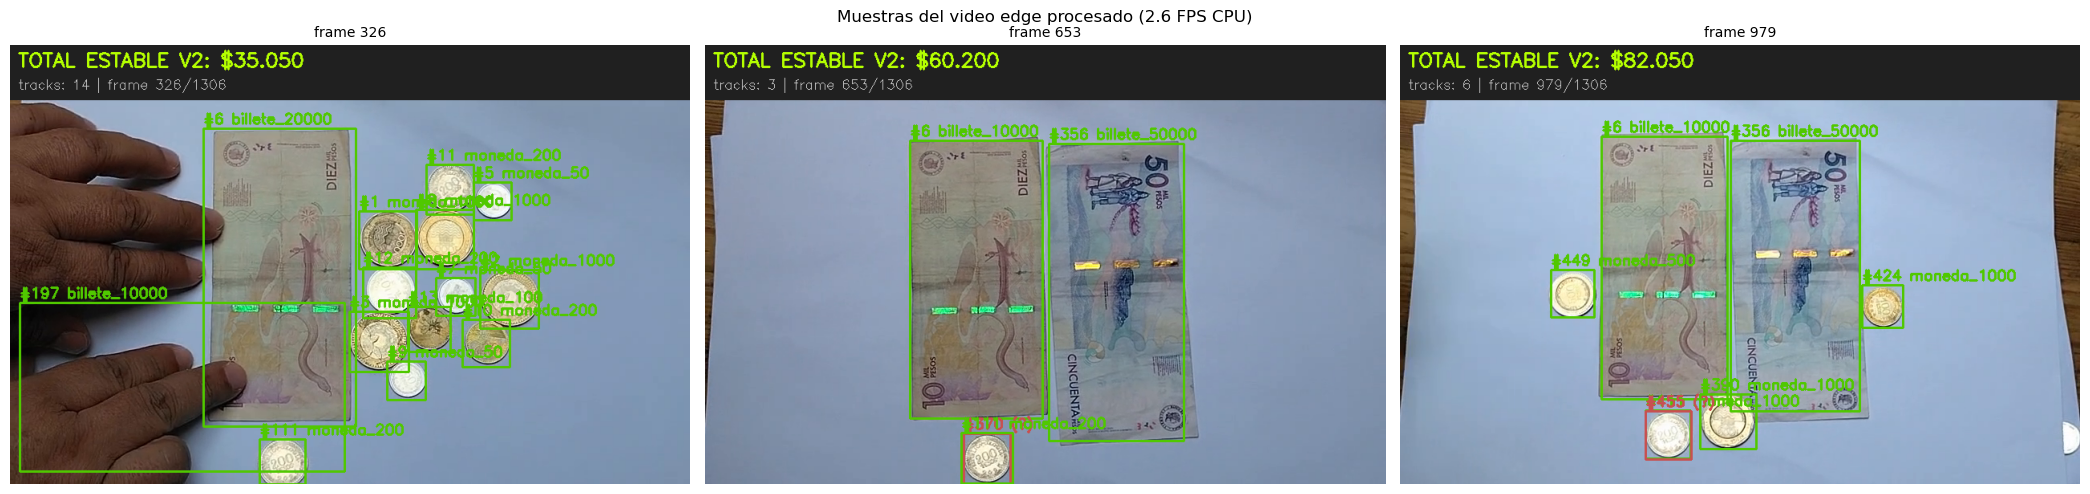

In [ ]:
if not VIDEO_PATH.exists():
    print(f'No existe {VIDEO_PATH}.')
    print('Sube un video corto (15-30s, ≤640p recomendado) a esa ruta para ejecutar la demo.')
else:
    # Leer propiedades
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames_in = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f'Video: {w}x{h} @ {fps_in:.1f} fps, {n_frames_in} frames')

    HUD_H = 70
    OUTPUT_VIDEO = OUTPUT_DIR / 'edge_video_v2.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps_in, (w, h + HUD_H))
    stable_v2 = StableCounterV2()

    sample_idxs = {max(1, n_frames_in // 4), max(1, n_frames_in // 2), max(1, (3 * n_frames_in) // 4)}
    sample_frames = []
    totals_display = []

    results_iter = model.track(
        source=str(VIDEO_PATH), tracker='bytetrack.yaml', persist=True,
        conf=VIDEO_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE,
        stream=True, device=device, verbose=False,
    )
    t0 = time.time()
    frame_idx = 0
    try:
        for r in results_iter:
            frame_idx += 1
            frame = r.orig_img.copy()
            tracks_this = []
            if r.boxes is not None and r.boxes.id is not None:
                cls_idx = r.boxes.cls.int().tolist()
                ids     = r.boxes.id.int().tolist()
                confs   = r.boxes.conf.tolist()
                for tid, ci, cf in zip(ids, cls_idx, confs):
                    tracks_this.append((tid, model.names[ci], cf))
            confirmed = stable_v2.update(tracks_this)
            d_total   = stable_v2.display_total(confirmed)
            totals_display.append(d_total)

            voted_by_tid = dict(confirmed)
            if r.boxes is not None and r.boxes.id is not None:
                xyxy = r.boxes.xyxy.cpu().numpy().astype(int)
                ids  = r.boxes.id.int().tolist()
                for (x1, y1, x2, y2), tid in zip(xyxy, ids):
                    voted = voted_by_tid.get(tid)
                    color = (0, 200, 80) if voted else (80, 80, 200)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    label = f'#{tid} {voted}' if voted else f'#{tid} (?)'
                    cv2.putText(frame, label, (x1, max(0, y1 - 6)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            hud = np.full((HUD_H, w, 3), 32, dtype=np.uint8)
            cv2.putText(hud, f'TOTAL ESTABLE V2: {format_currency(d_total)}',
                        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 180), 2)
            cv2.putText(hud, f'tracks: {len(confirmed)} | frame {frame_idx}/{n_frames_in}',
                        (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)
            out_frame = np.vstack([hud, frame])
            writer.write(out_frame)

            if frame_idx in sample_idxs:
                sample_frames.append((frame_idx, out_frame.copy()))
            if frame_idx % 60 == 0:
                print(f'  procesado frame {frame_idx}/{n_frames_in}')
    finally:
        writer.release()

    elapsed = time.time() - t0
    fps_out = frame_idx / elapsed if elapsed > 0 else 0.0
    print(f'\nVideo escrito : {OUTPUT_VIDEO}')
    print(f'FPS edge (CPU): {fps_out:.2f} ({frame_idx} frames en {elapsed:.1f}s)')

    if sample_frames:
        m = len(sample_frames)
        fig, axes = plt.subplots(1, m, figsize=(7 * m, 5))
        if m == 1: axes = [axes]
        for ax, (idx, f) in zip(axes, sample_frames):
            ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            ax.set_title(f'frame {idx}', fontsize=10)
            ax.axis('off')
        plt.suptitle(f'Muestras del video edge procesado ({fps_out:.1f} FPS CPU)')
        plt.tight_layout()
        plt.show()


## 6. Inferencia: webcam en vivo

Esta celda **abre una ventana cv2 nativa** con la cámara local y muestra el conteo
estable en tiempo real con `StableCounterV2`. Tecla `q` para salir.

> **Por defecto está deshabilitada** (`RUN_WEBCAM = False` en la celda 2). Para activarla:
>
> 1. Edita la celda 2 → cambia `RUN_WEBCAM = True`.
> 2. Re-ejecuta solo esta celda.

### Comportamiento

- HUD con `TOTAL ESTABLE: $...` actualizado por mediana móvil (V2).
- Cajas verdes = tracks confirmados (votados); rojas = tentativos.
- **Tope de seguridad:** procesa hasta `WEBCAM_MAX_FRAMES = 600` (~20s @ 30fps)
  para evitar bloqueos accidentales si no se presiona `q`.
- Si `SAVE_WEBCAM = True` (default), se guarda `outputs/edge/edge_webcam_v2.mp4`.

### Cómo cerrar correctamente

Se debe presionar `q` con la ventana de la cámara en foco. El `try/finally` libera el handle
de la cámara y cierra la ventana.

In [ ]:
if not RUN_WEBCAM:
    print('RUN_WEBCAM = False; saltando demo de webcam.')
    print('Para ejecutarla: cambia RUN_WEBCAM = True en la celda 2 y re-ejecuta esta celda.')
else:
    cap = cv2.VideoCapture(WEBCAM_INDEX)
    if not cap.isOpened():
        print(f'No se pudo abrir la webcam en index {WEBCAM_INDEX}.')
        print('Verifica que la cámara esté conectada y accesible (ls /dev/video*).')
    else:
        fps_in = cap.get(cv2.CAP_PROP_FPS) or 30
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 640
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
        cap.release()  # cerramos: model.track abrirá su propio handle

        HUD_H = 70
        writer = None
        if SAVE_WEBCAM:
            out_path = OUTPUT_DIR / 'edge_webcam_v2.mp4'
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(str(out_path), fourcc, fps_in, (w, h + HUD_H))

        stable_v2 = StableCounterV2()
        gui_available = True
        results_iter = model.track(
            source=WEBCAM_INDEX, tracker='bytetrack.yaml', persist=True,
            conf=VIDEO_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE,
            stream=True, device=device, verbose=False,
        )
        t0 = time.time()
        n_frames = 0
        try:
            for r in results_iter:
                n_frames += 1
                frame = r.orig_img.copy()
                tracks_this = []
                if r.boxes is not None and r.boxes.id is not None:
                    cls_idx = r.boxes.cls.int().tolist()
                    ids     = r.boxes.id.int().tolist()
                    confs   = r.boxes.conf.tolist()
                    for tid, ci, cf in zip(ids, cls_idx, confs):
                        tracks_this.append((tid, model.names[ci], cf))
                confirmed = stable_v2.update(tracks_this)
                d_total   = stable_v2.display_total(confirmed)
                voted_by_tid = dict(confirmed)
                if r.boxes is not None and r.boxes.id is not None:
                    xyxy = r.boxes.xyxy.cpu().numpy().astype(int)
                    ids  = r.boxes.id.int().tolist()
                    for (x1, y1, x2, y2), tid in zip(xyxy, ids):
                        voted = voted_by_tid.get(tid)
                        color = (0, 200, 80) if voted else (80, 80, 200)
                        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                        cv2.putText(frame, f'#{tid} {voted or "(?)"}',
                                    (x1, max(0, y1 - 6)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                hud = np.full((HUD_H, w, 3), 32, dtype=np.uint8)
                cv2.putText(hud, f'TOTAL ESTABLE: {format_currency(d_total)}',
                            (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 180), 2)
                cv2.putText(hud, f'tracks: {len(confirmed)} | q=salir',
                            (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)
                out_frame = np.vstack([hud, frame])

                if writer is not None:
                    writer.write(out_frame)
                if gui_available:
                    try:
                        cv2.imshow('edge_webcam', out_frame)
                        if cv2.waitKey(1) & 0xFF == ord('q'):
                            break
                    except cv2.error as e:
                        print(f'GUI no disponible: {e}')
                        print('Continuando solo con escritura a disco (sin preview).')
                        gui_available = False
                if n_frames >= WEBCAM_MAX_FRAMES:
                    print(f'Tope alcanzado ({WEBCAM_MAX_FRAMES} frames). Saliendo.')
                    break
        finally:
            if writer is not None:
                writer.release()
            try:
                cv2.destroyAllWindows()
            except Exception:
                pass

        elapsed = time.time() - t0
        fps_out = n_frames / elapsed if elapsed > 0 else 0.0
        print(f'Webcam: {n_frames} frames en {elapsed:.1f}s -> {fps_out:.2f} FPS')


1/1: 0... Success ✅ (inf frames of shape 640x480 at 30.00 FPS)



QFontDatabase: Cannot find font directory /home/wills/anaconda3/envs/master-IA/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/wills/anaconda3/envs/master-IA/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/wills/anaconda3/envs/master-IA/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/wills/anaconda3/envs/master-IA/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: C

Webcam: 63 frames en 29.2s -> 2.16 FPS
